# Task 4: Multi-Similarity Loss


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while (
    PROJECT_ROOT != PROJECT_ROOT.parent
    and not (PROJECT_ROOT / "pyproject.toml").exists()
):
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from pytorch_metric_learning import losses
from tqdm.auto import tqdm

from src.task4.config import (
    CONFIG_DIR,
    EARLY_STOPPING_PATIENCE,
    FINAL_EPOCHS,
    HISTORY_DIR,
    IMAGE_DIR,
    INPUT_SIZE,
    LABEL_COLUMN,
    LABEL_ID_COLUMN,
    MIN_CLASS_SIZE,
    MIN_DELTA,
    MODEL_DIR,
    N_TRIALS,
    PLOT_DIR,
    SEED,
    SPLIT_DIR,
    TUNING_EPOCHS,
    VAL_FRACTION,
)
from src.task4.data import (
    make_evaluation_loader,
    make_metric_training_loader,
    make_metric_validation_loss_loader,
)
from src.task4.models import ResNet18Encoder
from src.task4.preprocessing import (
    metric_eval_transform,
    metric_preprocessing_config,
    metric_train_transform,
)
from src.task4.retrieval import (
    evaluate_retrieval,
    extract_embeddings,
    k_reciprocal_rerank,
    retrieval_metrics,
    search_cosine,
)
from src.task4.training import (
    AMP_ENABLED,
    DEVICE,
    EarlyStopping,
    cpu_state_dict,
    evaluate_loss,
    new_optimizer_and_scheduler,
    set_seed,
    train_one_epoch,
)
from src.task4.tuning import create_study, load_best_params


## Data preparation and validation split


In [3]:
set_seed(SEED)
print("Device:", DEVICE, "| Mixed precision:", AMP_ENABLED)


Device: cuda | Mixed precision: True


In [4]:
outer_train_df = pd.read_csv(SPLIT_DIR / "train.csv")
with (CONFIG_DIR / "articleType_gender_label_encoder.json").open(
    encoding="utf-8"
) as file:
    label_encoder_config = json.load(file)

classes = label_encoder_config["classes"]
label_to_index = label_encoder_config["label_to_index"]

outer_train_df[LABEL_COLUMN] = (
    outer_train_df["articleType"].str.strip()
    + "__"
    + outer_train_df["gender"].str.strip()
)

outer_train_df[LABEL_ID_COLUMN] = (
    outer_train_df[LABEL_COLUMN].map(label_to_index).astype("int64")
)

outer_class_counts = outer_train_df[LABEL_COLUMN].value_counts()
eligible_labels = set(outer_class_counts[outer_class_counts >= MIN_CLASS_SIZE].index)
development_df = outer_train_df[
    outer_train_df[LABEL_COLUMN].isin(eligible_labels)
].copy()


In [5]:
inner_stratify_columns = ["articleType", "gender"]
inner_stratify_features = pd.get_dummies(
    development_df[inner_stratify_columns].astype(str),
    prefix=inner_stratify_columns,
)
inner_splitter = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=VAL_FRACTION,
    random_state=SEED,
)
inner_train_idx, inner_val_idx = next(
    inner_splitter.split(development_df, inner_stratify_features)
)
train_df = development_df.iloc[inner_train_idx].copy()
val_df = development_df.iloc[inner_val_idx].copy()

train_counts = train_df[LABEL_ID_COLUMN].value_counts()
valid_label_ids = train_counts[train_counts >= MIN_CLASS_SIZE].index
train_df = train_df[train_df[LABEL_ID_COLUMN].isin(valid_label_ids)].copy()
val_df = val_df[val_df[LABEL_ID_COLUMN].isin(valid_label_ids)].copy()

overlap = set(train_df["id"]) & set(val_df["id"])
if overlap:
    raise ValueError(f"Inner split contains {len(overlap)} overlapping IDs")
if val_df[LABEL_ID_COLUMN].isna().any():
    raise ValueError("Inner validation contains an unmapped label")


In [6]:
gallery_parts = []
for _, group in train_df.groupby(LABEL_COLUMN, sort=True):
    sample_size = min(20, len(group))
    gallery_parts.append(group.sample(sample_size, random_state=SEED))

tuning_gallery_df = pd.concat(gallery_parts).sort_values("id").reset_index(drop=True)

print(f"Model train/validation: {len(train_df):,}/{len(val_df):,}")
print("Excluded rare rows:", len(outer_train_df) - len(development_df))
print("Tuning gallery rows:", len(tuning_gallery_df))


Model train/validation: 30,389/3,378
Excluded rare rows: 153
Tuning gallery rows: 2861


In [ ]:
def make_multi_similarity_loaders(train_frame, gallery_frame, query_frame):
    return {
        "train": make_metric_training_loader(train_frame, metric_train_transform, IMAGE_DIR),
        "gallery": make_evaluation_loader(gallery_frame, metric_eval_transform, IMAGE_DIR),
        "query": make_evaluation_loader(query_frame, metric_eval_transform, IMAGE_DIR),
    }

def compute_multi_similarity_loss(model, loss_function, batch):
    images = batch["image"].to(DEVICE, non_blocking=True)
    labels = batch["label"].to(DEVICE, non_blocking=True)
    return loss_function(model(images), labels)


## Hyperparameter tuning


In [ ]:
def multi_similarity_objective(trial: optuna.Trial):
    parameters = {
        "learning_rate": trial.suggest_float("learning_rate", 3e-5, 1e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 3e-4, log=True),
        "alpha": trial.suggest_float("alpha", 1.0, 3.0),
        "beta": trial.suggest_float("beta", 20.0, 80.0),
        "base": trial.suggest_float("base", 0.3, 0.7),
    }
    set_seed(SEED)
    model = ResNet18Encoder()
    loss_function = losses.MultiSimilarityLoss(
        alpha=parameters.get("alpha", 2.0),
        beta=parameters.get("beta", 50.0),
        base=parameters.get("base", 0.5),
    )
    model, loss_function = model.to(DEVICE), loss_function.to(DEVICE)
    loaders = make_multi_similarity_loaders(train_df, tuning_gallery_df, val_df)
    optimizer, scheduler = new_optimizer_and_scheduler(model, parameters)
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    best_score = -math.inf
    for epoch in tqdm(range(1, TUNING_EPOCHS + 1), desc="multi-similarity tuning"):
        train_one_epoch(
            model,
            loss_function,
            compute_multi_similarity_loss,
            loaders["train"],
            optimizer,
            scaler,
            epoch,
        )
        score = evaluate_retrieval(model, loaders["gallery"], loaders["query"])[
            "mAP@10"
        ]
        scheduler.step(score)
        best_score = max(best_score, score)
        trial.report(score, step=epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return best_score

In [ ]:
multi_similarity_study = create_study("task4_multi_similarity")
multi_similarity_study.optimize(multi_similarity_objective, n_trials=N_TRIALS)

print("multi_similarity", "best parameters:", multi_similarity_study.best_params)
print("multi_similarity", "tuned validation mAP@10:", multi_similarity_study.best_value)


[I 2026-09-07 19:12:11,108] Using an existing study with `study_name='task4_multi_similarity'` instead of creating a new one.


multi-similarity tuning:   0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-09-07 19:16:35,630] Trial 1 finished with value: 0.3615001127745355 and parameters: {'learning_rate': 0.00011155792840695785, 'weight_decay': 0.0002264824818951685, 'alpha': 2.46398788362281, 'beta': 55.919509051822196, 'base': 0.36240745617697456}. Best is trial 1 with value: 0.3615001127745355.


multi-similarity tuning:   0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-09-07 19:21:08,118] Trial 2 finished with value: 0.3536899084020162 and parameters: {'learning_rate': 5.184202941199549e-05, 'weight_decay': 1.3927723945289012e-06, 'alpha': 2.73235229154987, 'beta': 56.06690070459253, 'base': 0.5832290311184182}. Best is trial 1 with value: 0.3615001127745355.


...

multi-similarity tuning:   0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-09-07 20:15:26,986] Trial 19 finished with value: 0.40111169162586424 and parameters: {'learning_rate': 0.0002300140428856256, 'weight_decay': 0.00024674825943701086, 'alpha': 1.4004512241552494, 'beta': 39.26901626390101, 'base': 0.6621456127683757}. Best is trial 7 with value: 0.42800359801673454.


multi-similarity tuning:   0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-09-07 20:16:22,253] Trial 20 pruned. 


multi_similarity best parameters: {'learning_rate': 0.0007688234477542377, 'weight_decay': 4.35410221061555e-06, 'alpha': 1.41883053518728, 'beta': 51.58344767556214, 'base': 0.6471101913613169}


## Final training


In [9]:
multi_similarity_history = []
multi_similarity_best_epoch = 0
multi_similarity_best_score = -math.inf

multi_similarity_best_params, multi_similarity_tuning_best_value = load_best_params("task4_multi_similarity")
print("multi_similarity loaded Optuna best parameters:", multi_similarity_best_params)
print("multi_similarity tuned validation mAP@10:", multi_similarity_tuning_best_value)

parameters = multi_similarity_best_params
set_seed(SEED)
model = ResNet18Encoder()
loss_function = losses.MultiSimilarityLoss(
    alpha=parameters.get("alpha", 2.0),
    beta=parameters.get("beta", 50.0),
    base=parameters.get("base", 0.5),
)
model, loss_function = model.to(DEVICE), loss_function.to(DEVICE)
loaders = make_multi_similarity_loaders(train_df, tuning_gallery_df, val_df)
val_loss_loader = make_metric_validation_loss_loader(
    val_df, metric_eval_transform, IMAGE_DIR
)


In [10]:
optimizer, scheduler = new_optimizer_and_scheduler(model, parameters)
scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
stopper = EarlyStopping(EARLY_STOPPING_PATIENCE, MIN_DELTA)
best_state = None


In [11]:
for epoch in tqdm(range(1, FINAL_EPOCHS + 1), desc="multi_similarity final"):
    train_loss = train_one_epoch(
        model,
        loss_function,
        compute_multi_similarity_loss,
        loaders["train"],
        optimizer,
        scaler,
        epoch,
    )
    val_loss = evaluate_loss(model, loss_function, compute_multi_similarity_loss, val_loss_loader)
    metrics = evaluate_retrieval(model, loaders["gallery"], loaders["query"])
    score = metrics["mAP@10"]
    scheduler.step(score)
    if stopper.update(score):
        best_state = cpu_state_dict(model)
        multi_similarity_best_epoch = epoch
    multi_similarity_history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_map_at_10": score,
        }
    )
    print(
        "multi_similarity",
        epoch,
        "loss:",
        round(train_loss, 4),
        "mAP@10:",
        round(score, 4),
    )
    if stopper.should_stop:
        break


multi_similarity final:   0%|          | 0/60 [00:00<?, ?it/s]

multi_similarity 1 loss: 1.0473 mAP@10: 0.1936
multi_similarity 2 loss: 0.9696 mAP@10: 0.2236
multi_similarity 3 loss: 0.9362 mAP@10: 0.231
multi_similarity 4 loss: 0.916 mAP@10: 0.2676
multi_similarity 5 loss: 0.8985 mAP@10: 0.2726
multi_similarity 6 loss: 0.8856 mAP@10: 0.2931
multi_similarity 7 loss: 0.8806 mAP@10: 0.3012
multi_similarity 8 loss: 0.868 mAP@10: 0.3151
multi_similarity 9 loss: 0.8606 mAP@10: 0.3284
multi_similarity 10 loss: 0.8538 mAP@10: 0.3511
multi_similarity 11 loss: 0.8448 mAP@10: 0.3431
multi_similarity 12 loss: 0.8426 mAP@10: 0.3697
multi_similarity 13 loss: 0.8355 mAP@10: 0.363
multi_similarity 14 loss: 0.8331 mAP@10: 0.3757
multi_similarity 15 loss: 0.8267 mAP@10: 0.3837
multi_similarity 16 loss: 0.8228 mAP@10: 0.3727
multi_similarity 17 loss: 0.8252 mAP@10: 0.4087
multi_similarity 18 loss: 0.8187 mAP@10: 0.3881
multi_similarity 19 loss: 0.8123 mAP@10: 0.4193
multi_similarity 20 loss: 0.8132 mAP@10: 0.4323
multi_similarity 21 loss: 0.8088 mAP@10: 0.4349
multi

In [12]:
model.load_state_dict(best_state)
multi_similarity_best_score = stopper.best_score
multi_similarity_model = model
print(
    "multi_similarity",
    "best epoch:",
    multi_similarity_best_epoch,
    "best mAP@10:",
    multi_similarity_best_score,
)


multi_similarity best epoch: 60 best mAP@10: 0.5919340451051153


## Training history and learning curves


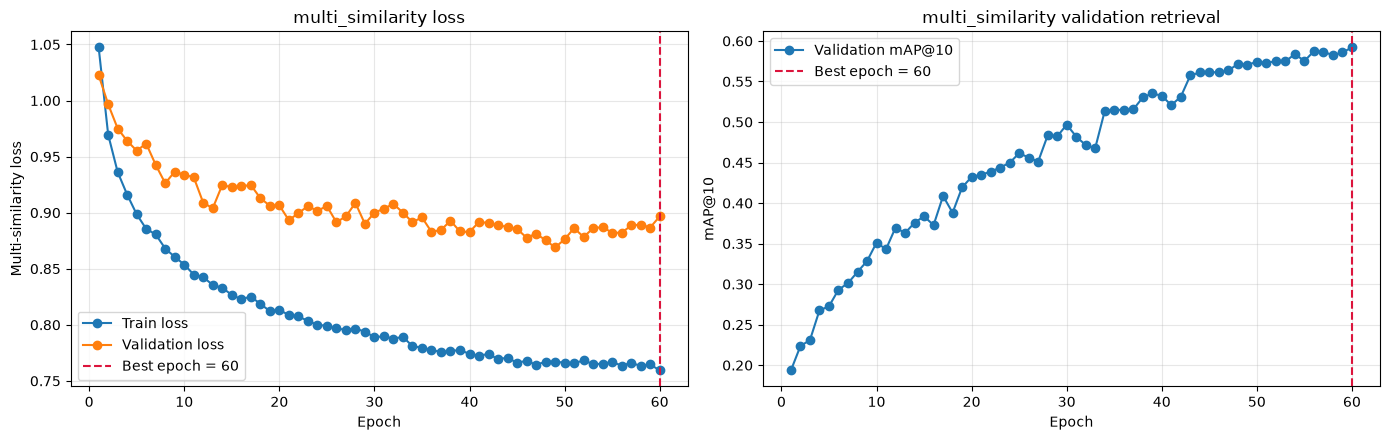

In [13]:
HISTORY_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

history_path = HISTORY_DIR / "multi_similarity_history.csv"
pd.DataFrame(multi_similarity_history).sort_values("epoch").to_csv(
    history_path, index=False
)
history_df = pd.read_csv(history_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(
    history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss"
)
axes[0].plot(
    history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss"
)
axes[0].axvline(
    multi_similarity_best_epoch,
    color="crimson",
    linestyle="--",
    label=f"Best epoch = {multi_similarity_best_epoch}",
)
axes[0].set_title("multi_similarity loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Multi-similarity loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    history_df["epoch"],
    history_df["val_map_at_10"],
    marker="o",
    label="Validation mAP@10",
)
axes[1].axvline(
    multi_similarity_best_epoch,
    color="crimson",
    linestyle="--",
    label=f"Best epoch = {multi_similarity_best_epoch}",
)
axes[1].set_title("multi_similarity validation retrieval")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("mAP@10")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(
    PLOT_DIR / "multi_similarity_learning_curves.png", dpi=150, bbox_inches="tight"
)
plt.show()


## Save model and evaluate retrieval


In [14]:
model_directory = MODEL_DIR / "multi_similarity"
model_directory.mkdir(parents=True, exist_ok=True)
checkpoint = {
    "model_name": "multi_similarity",
    "model_state_dict": cpu_state_dict(multi_similarity_model),
    "model_config": {
        "backbone": "resnet18",
        "pretrained": False,
        "input_size": list(INPUT_SIZE),
        "embedding_dimension": 512,
        "class_count": len(classes),
    },
    "best_params": multi_similarity_best_params,
    "best_epoch": multi_similarity_best_epoch,
    "best_val_map_at_10": multi_similarity_best_score,
    "preprocessing_config": metric_preprocessing_config,
    "label_to_index": label_to_index,
    "gallery_scope": "eligible_inner_training",
    "random_seed": SEED,
}
torch.save(checkpoint, model_directory / "best.pt")
print("Saved:", model_directory / "best.pt")


Saved: /workspace/Machine-Learning-Assignment-2/artifacts/task4/models/multi_similarity/best.pt


In [15]:
gallery_loader = make_evaluation_loader(train_df, metric_eval_transform, IMAGE_DIR)
gallery_embeddings, gallery_ids, gallery_labels = extract_embeddings(
    multi_similarity_model, gallery_loader
)
np.save(model_directory / "gallery_embeddings.npy", gallery_embeddings)
np.save(model_directory / "gallery_ids.npy", gallery_ids)


In [16]:
query_loader = make_evaluation_loader(val_df, metric_eval_transform, IMAGE_DIR)
query_embeddings, _, query_labels = extract_embeddings(
    multi_similarity_model, query_loader
)


In [18]:
_, base_indices, index = search_cosine(query_embeddings, gallery_embeddings)
reranked_indices = k_reciprocal_rerank(query_embeddings, gallery_embeddings, index)
print(
    "multi_similarity",
    "base:",
    retrieval_metrics(base_indices, query_labels, gallery_labels),
)
print(
    "multi_similarity",
    "reranked:",
    retrieval_metrics(reranked_indices, query_labels, gallery_labels),
)


multi_similarity base: {'Precision@1': 0.7696862048549438, 'Recall@1': 0.003464906902610772, 'Precision@5': 0.7551805802249852, 'Recall@5': 0.017186212908777712, 'Precision@10': 0.7497631734754292, 'Recall@10': 0.032535925098810536, 'mAP@10': 0.6934661928961441}
multi_similarity reranked: {'Precision@1': 0.7471876850207223, 'Recall@1': 0.00349411055659315, 'Precision@5': 0.7476613380698639, 'Recall@5': 0.01722821842646969, 'Precision@10': 0.7456779159265837, 'Recall@10': 0.03256584928193291, 'mAP@10': 0.6901091416683114}
